# Graphs, Connectivity, and Shortest Paths in Python

## 1) Graphs

Graphs are useful whenever we model relationships between entities.

<img width="750" alt="Example semantic relations graph on Neo4J" src="../img/example_graph.png">

_Above is a semantic relation graph generated via ML tools examining the video [here](https://www.freepik.com/free-video/little-boy-playing-with-eco-toy_1195856#fromView=popular&page=1&position=0&uuid=be4a0cb2-33de-4cb0-84e4-fcf4ce6ba215). More information will be shared on the demo in this session._ 

For this course, graphs matter because they let us model structure efficiently and solve practical problems such as connectivity and pathfinding.

### 1.1) What is a graph?

A graph consists of:
1. __nodes__ or __vertices__, which represent objects
2. __edges__, which represent relationships between objects

A graph may be:
1. __undirected__, where a connection goes both ways
2. __directed__, where a connection has a direction

Edges may also have __weights__, such as distance, cost, or time.

### 1.2) Graph representation in Python

A common lightweight representation is an __adjacency list__.

This is efficient for sparse graphs and easy to read.

#### Adjacency list for an unweighted graph

In [1]:
graph_unweighted = {
    "A": ["B", "C"],
    "B": ["A", "D"],
    "C": ["A", "D", "E"],
    "D": ["B", "C", "F"],
    "E": ["C"],
    "F": ["D"],
}

graph_unweighted

{'A': ['B', 'C'],
 'B': ['A', 'D'],
 'C': ['A', 'D', 'E'],
 'D': ['B', 'C', 'F'],
 'E': ['C'],
 'F': ['D']}

#### Adjacency list for a weighted graph

In [2]:
graph_weighted = {
    "A": [("B", 4), ("C", 2)],
    "B": [("A", 4), ("D", 5)],
    "C": [("A", 2), ("D", 1), ("E", 7)],
    "D": [("B", 5), ("C", 1), ("F", 3)],
    "E": [("C", 7), ("F", 2)],
    "F": [("D", 3), ("E", 2)],
}

graph_weighted

{'A': [('B', 4), ('C', 2)],
 'B': [('A', 4), ('D', 5)],
 'C': [('A', 2), ('D', 1), ('E', 7)],
 'D': [('B', 5), ('C', 1), ('F', 3)],
 'E': [('C', 7), ('F', 2)],
 'F': [('D', 3), ('E', 2)]}

#### Visualising a graph

```bash
pip install matplotlib networkx
```

💭 If you are dealing with large graphs and have access to GPUs, use `nx-cugraph` instead of `networkx` for acceleration. You can find more information about it [here](https://rapids.ai/nx-cugraph/).

<hr style='border: none; height: 1px; background: linear-gradient(to right, transparent, #9ca3af, transparent); margin: 1rem 0;'>

Optional import cell below for text colouring in prints to make the output more apparent.

If you want to run it, install `rich`: 
```bash
pip install rich
```

If you do not, the rest of the cells will not be affected as it only changes output when explicitly used.

In [3]:
from rich import get_console, print

# Set up the console for rich output, avoid issues in Jupyter notebooks.
console = get_console()
console.is_jupyter = False

<hr style='border: none; height: 1px; background: linear-gradient(to right, transparent, #9ca3af, transparent); margin: 1rem 0;'>

In [4]:
import networkx as nx
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "monospace"
plt.rcParams["font.monospace"] = ["Courier"]

In [5]:
# Create a graph via NetworkX and add edges with weights.
G = nx.Graph()
edges = [
    ("A", "B", 4),
    ("A", "C", 2),
    ("B", "D", 5),
    ("C", "D", 1),
    ("C", "E", 7),
    ("D", "F", 3),
    ("E", "F", 2),
]

for u, v, w in edges:
    G.add_edge(u, v, weight=w)

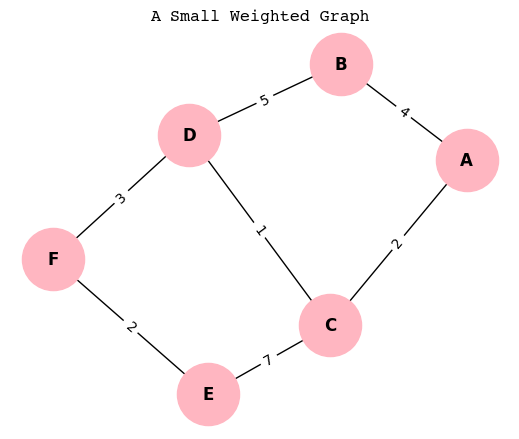

In [6]:
def draw_weighted_graph(G, title="A Small Weighted Graph"):
    pos = nx.spring_layout(G, seed=13)

    plt.figure(figsize=(5, 4))
    nx.draw(
        G,
        pos,
        with_labels=True,
        node_size=2000,
        node_color="lightpink",
        font_weight="bold",
    )
    edge_labels = nx.get_edge_attributes(G, "weight")
    nx.draw_networkx_edge_labels(
        G,
        pos,
        edge_labels=edge_labels,
    )
    plt.title(title)
    plt.show()


draw_weighted_graph(G)

#### Edge centric vs. Node centric Representation

While typical adjacency lists prefer node centric, `networkx` prefers edge centric input.

In [7]:
# Let's convert graph_unweighted (adjacency list) to a NetworkX graph for comparison:
G_converted_unweighted = nx.Graph()

for node, neighbors in graph_unweighted.items():
    for neighbor in neighbors:
        G_converted_unweighted.add_edge(node, neighbor)

In [8]:
# Convert graph_weighted (adjacency list) to a NetworkX graph:
G_converted_weighted = nx.Graph()

for node, neighbors in graph_weighted.items():
    for neighbor, weight in neighbors:
        G_converted_weighted.add_edge(node, neighbor, weight=weight)

# G_converted_weighted is indeed the same as the graph G, check out the above `edges` variable once again.

Below side by side visualizations require two Python libraries.

If you prefer not to install them, you can still view the results in the saved notebook without running the cells.
```bash
pip install ipywidgets ipykernel
```

In [9]:
import ipywidgets as widgets
from IPython.display import display

box_layout = widgets.Layout(width="50%", border="1px solid lightgray", padding="10px")

In [10]:
def create_side_by_side():
    left = widgets.Output(layout=box_layout)
    right = widgets.Output(layout=box_layout)
    container = widgets.HBox([left, right], layout=widgets.Layout(gap="20px"))
    display(container)
    return left, right

In [11]:
left, right = create_side_by_side()

with left:
    left.clear_output()
    print("Adjacency list:")
    print("\n".join(f"{k}: {v}" for k, v in graph_unweighted.items()))

with right:
    right.clear_output()
    print("NetworkX edges:")
    print("\n".join(str(edge) for edge in G_converted_unweighted.edges()))

In [12]:
left, right = create_side_by_side()

with left:
    left.clear_output()
    print("Adjacency list:")
    print("\n".join(f"{k}: {v}" for k, v in graph_weighted.items()))

with right:
    right.clear_output()
    print("NetworkX edges:")
    print("\n".join(str(edge) for edge in G_converted_weighted.edges(data=True)))

## 2) Connectivity

A graph is connected if every node can be reached from every other node.

This information is useful before delving into the topic of **shortest path**s, because if two nodes are not connected, no path exists.

### 2.1) Breadth first search (BFS) for reachability

BFS, explores a graph layer by layer.

For an unweighted graph, BFS can also find the shortest path in terms of number of edges.

#### BFS from scratch

In [13]:
from collections import deque


def bfs_reachable(graph, start):
    visited = set([start])
    queue = deque([start])

    while queue:
        node = queue.popleft()
        for neighbor in graph[node]:
            if neighbor not in visited:
                visited.add(neighbor)
                queue.append(neighbor)

    return visited


reachable_from_a = bfs_reachable(graph_unweighted, "A")
reachable_from_a

{'A', 'B', 'C', 'D', 'E', 'F'}

⚠️ __Notice the use of `deque`!__

💭 Do you think another data structure could have been used here?

#### BFS via `networkx`

In [14]:
# For this task, below two functions can be used.
reachable_nx = nx.node_connected_component(G_converted_unweighted, "A")
tree = nx.bfs_tree(G_converted_unweighted, source="A")

print("Reachable Components:", reachable_nx)
print("Tree nodes:", list(tree.nodes()))
print("Tree edges:", list(tree.edges()))

Reachable Components:
{'E', 'A', 'C', 'F', 'B', 'D'}
Tree nodes:
['A', 'B', 'C', 'D', 'E', 'F']
Tree edges:
[('A', 'B'), ('A', 'C'), ('B', 'D'), ('C', 'E'), ('D', 'F')]


### 2.2) Traversal, BFS versus DFS (Depth-First Search)

Two classic traversal methods are:
1. BFS, breadth first search
2. DFS, depth first search

Both visit the same nodes, but they explore the graph in different ways:
- BFS explores the graph step by step, starting from the source and moving outward level by level. It first visits all nodes that are close, then moves to nodes that are further away.
- DFS starts at the source and follows one path as far as it can. When it reaches a dead end, it goes back and tries a different path.

Useful distinction:
1. BFS is preferred for shortest path in unweighted graphs.
2. DFS is useful for exploration, cycle detection, and structural checks.

📘 Check out *Introduction to Algorithms* by Thomas H. Cormen et al., p. 594, Sections 22.2 and 22.3 for more information on this topic.

The free online version of the book is available under "Main Learning Materials" on Spaces.

In [15]:
T_bfs = nx.bfs_tree(G_converted_unweighted, source="A")
T_dfs = nx.dfs_tree(G_converted_unweighted, source="A")

left, right = create_side_by_side()

with left:
    left.clear_output()
    print("Adjacency list:")
    print("\n".join(f"{k}: {v}" for k, v in graph_unweighted.items()))
    print("BFS Tree nodes:", list(T_bfs.nodes()))
    print("DFS Tree nodes:", list(T_dfs.nodes()))

with right:
    right.clear_output()
    pos = nx.spring_layout(G_converted_unweighted, seed=13)

    plt.figure(figsize=(10, 4))

    # BFS
    plt.subplot(1, 2, 1)
    nx.draw(G_converted_unweighted, pos, node_color="lightgray", with_labels=True)
    nx.draw_networkx_edges(T_bfs, pos, edge_color="red", width=2)
    plt.title("BFS Tree")

    # DFS
    plt.subplot(1, 2, 2)
    nx.draw(G_converted_unweighted, pos, node_color="lightgray", with_labels=True)
    nx.draw_networkx_edges(T_dfs, pos, edge_color="blue", width=2)
    plt.title("DFS Tree")

    plt.show()

ℹ️ **The tree is just a record of the traversal. It is not a new graph, it is a subset of edges that shows how BFS|DFS explored the graph.**

Here, graph is the world, and traversal tree is the path we took through it.

## 3) The Shortest Path Problem

The shortest path problem asks:

Given a start node and a target node, what is the minimum cost path between them

The meaning of cost depends on the setting:
- number of steps
- distance
- travel time
- energy
- risk
- price

Choice of algorithm depends on the graph.

### 3.1) Shortest path in unweighted graphs

If all edges have equal cost, a shortest path is found in terms of number of edges.

BFS is one of the algorithms used for that.

In [16]:
# G_converted_unweighted was already set via the graph_unweighted variable earlier.
nx.shortest_path(G_converted_unweighted, source="A", target="F")

['A', 'B', 'D', 'F']

### 3.1) Shortest path in weighted graphs

#### __Dijkstra’s algorithm__

When edges have __non negative__ weights, Dijkstra’s algorithm is a standard choice.

Main idea:
1. Keep track of the best known distance to each node.
2. Always expand the currently cheapest unexplored node.
3. Update neighbors if a better route is found.

In [24]:
# Let's remember and visualize our weighted graph again:
left, right = create_side_by_side()

with left:
    left.clear_output()
    print("Weighted Graph Edges:\n")
    print("\n".join(str(edge) for edge in G_converted_weighted.edges(data=True)))

with right:
    right.clear_output()
    draw_weighted_graph(G_converted_weighted, title="Weighted Graph")

In [18]:
# -------------------- Compute Dijkstra shortest path (weighted) --------------------
# Shortest path will be decided based on "weights" below.
# Supported `method` options for below function call: 'dijkstra', 'bellman-ford'
shortest_path = nx.shortest_path(
    G, source="A", target="F", weight="weight", method="dijkstra"
)
path_cost = nx.shortest_path_length(
    G, source="A", target="F", weight="weight", method="dijkstra"
)

print(f"Shortest path from A to F: {shortest_path} with total cost {path_cost}.")

Shortest path from A to F: ['A', 'C', 'D', 'F'] with total cost 6.


#### Visualize Dijkstra's Path

In [19]:
left, right = create_side_by_side()

with left:
    left.clear_output()
    draw_weighted_graph(G, title="Original Weighted Graph")

with right:
    right.clear_output()
    path_edges = list(zip(shortest_path[:-1], shortest_path[1:]))

    pos = nx.spring_layout(G, seed=13)

    plt.figure(figsize=(5, 4))

    # Draw full graph
    nx.draw(
        G,
        pos,
        with_labels=True,
        node_size=1800,
        node_color="lightpink",
        edge_color="lightgray",
        width=2,
        font_weight="bold",
    )

    # Highlight shortest path nodes and edges
    nx.draw_networkx_nodes(
        G, pos, nodelist=shortest_path, node_color="lightblue", node_size=1900
    )
    nx.draw_networkx_edges(G, pos, edgelist=path_edges, edge_color="teal", width=4)

    # Draw edge weights
    edge_labels = nx.get_edge_attributes(G, "weight")
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)

    plt.title(
        f"Dijkstra Shortest Path: {' -> '.join(shortest_path)} (cost={path_cost})"
    )
    plt.show()

⭐ BFS is what Dijkstra becomes when all paths cost the same.

In [20]:
# Supported `method` options: 'dijkstra', 'bellman-ford'
nx.shortest_path(G, source="A", target="F", method="dijkstra")

['A', 'B', 'D', 'F']

## 4) Time Complexity Discussion

1. BFS → O(V + E)
2. DFS → O(V + E)
3. Dijkstra with a priority queue → O(?)

Where:
- V is the number of vertices
- E is the number of edges